# Image Classification with CNN for Malaria Data

In [1]:
import cv2 # Resim okumak için
import pandas as pd # dosya okumak için
from sklearn.model_selection import train_test_split
import numpy as np
import os
from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Explorty Data Analysis

In [3]:
labels=["Parasitized","Uninfected"]
img_path="cell_images/"

In [4]:
img_list = []
label_list = []

valid_extensions = ('.png', '.jpg', '.jpeg')

for label in labels:
    folder = os.path.join(img_path, label)
    for img_file in os.listdir(folder):
        # Yalnızca resim dosyalarını listeye ekle
        if img_file.lower().endswith(valid_extensions):
            img_list.append(os.path.join(folder, img_file))
            label_list.append(label)

In [5]:
df=pd.DataFrame({"img":img_list,"label":label_list})

In [6]:
df

,img,label
0,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized
1,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized
2,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized
3,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized
4,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized
...,...,...
27553,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected
27554,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected
27555,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected
27556,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected


In [7]:
d=({"Parasitized":1,"Uninfected":0})
df["label_encoded"]=df["label"].map(d)

In [8]:
df

,img,label,label_encoded
0,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized,1
1,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized,1
2,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized,1
3,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized,1
4,cell_images/Parasitized\C100P61ThinF_IMG_20150...,Parasitized,1
...,...,...,...
27553,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected,0
27554,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected,0
27555,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected,0
27556,cell_images/Uninfected\C99P60ThinF_IMG_2015091...,Uninfected,0


In [9]:
x=[]
for img in df["img"]:
    img=cv2.imread(str(img))
    img=cv2.resize(img,(170,170))
    img=img/255.0 #normalizing
    x.append(img)

In [10]:
x=np.array(x)

In [11]:
x.shape

(27558, 170, 170, 3)

In [12]:
y=df["label_encoded"]

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20)

In [14]:
y_train=np.array(y_train,dtype=np.int32)
y_test=np.array(y_test,dtype=np.int32)

In [17]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping
model = Sequential()
model.add(Input(shape=(170, 170, 3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,               # val_loss 2 epoch boyunca düşmezse durdur
    restore_best_weights=True # En yüksek val başarısı veren epoch ağırlıklarını seç
)

In [19]:
history = model.fit(x_train,y_train,validation_data=(x_test, y_test),epochs=10,batch_size=64,callbacks=[early_stop],verbose=1)

Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.7722 - loss: 0.4799 - val_accuracy: 0.9263 - val_loss: 0.2801
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 535s 1s/step - accuracy: 0.9345 - loss: 0.2117 - val_accuracy: 0.9430 - val_loss: 0.1784
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.9454 - loss: 0.1717 - val_accuracy: 0.9434 - val_loss: 0.1506
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.9516 - loss: 0.1549 - val_accuracy: 0.9472 - val_loss: 0.1516
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.9537 - loss: 0.1421 - val_accuracy: 0.9508 - val_loss: 0.1618


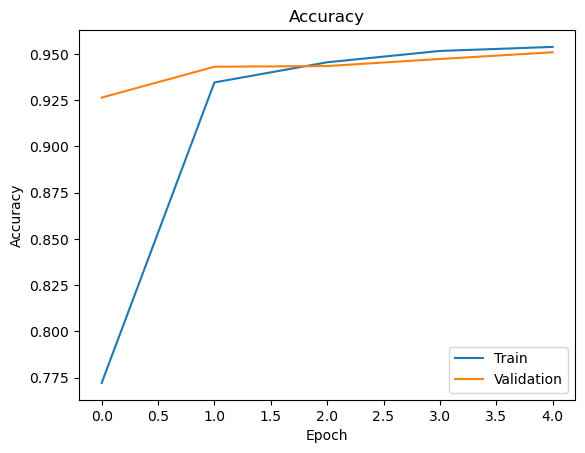

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

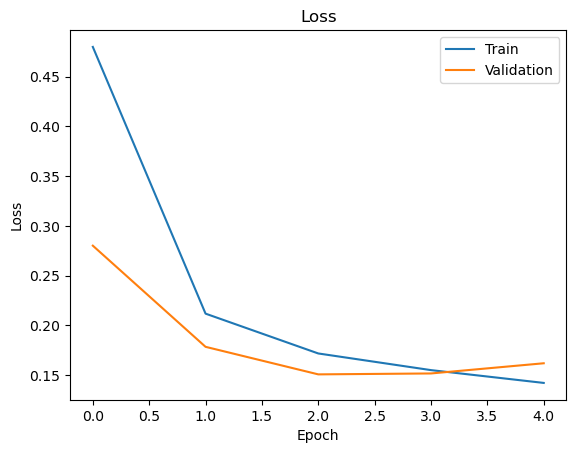

In [21]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

173/173 ━━━━━━━━━━━━━━━━━━━━ 36s 204ms/step
Classification Report:

              precision    recall  f1-score   support

  Uninfected       0.95      0.94      0.94      2715
 Parasitized       0.94      0.95      0.94      2797

    accuracy                           0.94      5512
   macro avg       0.94      0.94      0.94      5512
weighted avg       0.94      0.94      0.94      5512



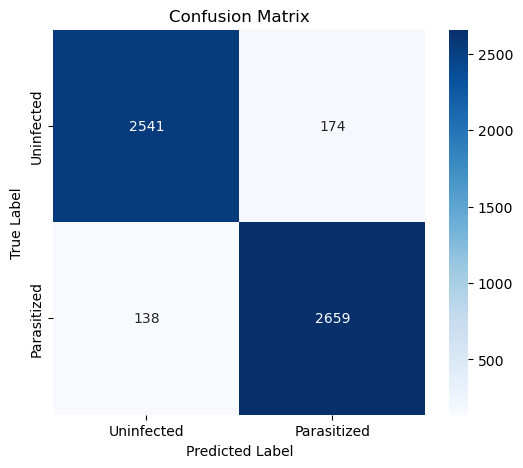

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict probabilities on test set
y_pred_prob = model.predict(x_test)

# 2. Convert probabilities to binary classes (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Print Classification Report (Precision, Recall, F1-Score)
target_names = ["Uninfected", "Parasitized"]
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# 4. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [23]:
from keras.models import load_model
model.save("malaria_detector_model.keras")